# Import Libraries

In [2]:
!pip install pandas numpy matplotlib seaborn joblib scikit-learn xgboost
!pip install skl2onnx onnx
import pandas, numpy, matplotlib, seaborn, joblib, sklearn, xgboost
print("All libraries installed successfully")

All libraries installed successfully


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score

# Load & Inspect Data

In [4]:
data = pd.read_csv("dataset.csv")
print(data.shape)
print(data.head())
print(data.describe())

(5000, 57)
  PatientID             AgeGroup       Department      AppointmentType  \
0   P100000        Adult (36-60)      Orthopedics          New Patient   
1   P100001        Adult (36-60)       Cardiology  Specialist Referral   
2   P100002  Young Adult (18-35)  General Surgery  Specialist Referral   
3   P100003        Adult (36-60)        Emergency          Urgent Care   
4   P100004         Senior (61+)       Cardiology          Urgent Care   

  InsuranceType ArrivalMethod   VisitDate   AppointmentTime ActualArrivalTime  \
0       Private       Walk-in  15-03-2024  15-03-2024 14:00  15-03-2024 13:32   
1      Self-pay     Scheduled  01-01-2024  01-01-2024 09:45  01-01-2024 09:36   
2      Medicaid     Scheduled  19-01-2024  19-01-2024 16:15  19-01-2024 16:07   
3           NaN     Emergency  27-03-2024  27-03-2024 11:00  27-03-2024 10:59   
4      Medicare     Scheduled  10-03-2024  10-03-2024 16:45  10-03-2024 16:48   

        CheckInTime  ... TestsToDischargeTime TotalTimeIn

# Feature Engineering

In [5]:
age_map = {
    "Child (0-17)": 10,
    "Adult (18-40)": 30,
    "Middle-aged (41-60)": 50,
    "Senior (61+)": 70
}

data["AgeNumeric"] = data["AgeGroup"].map(age_map).fillna(30)
data["ArrivalHour_sin"] = np.sin(2*np.pi*data["ArrivalHour"]/24)
data["ArrivalHour_cos"] = np.cos(2*np.pi*data["ArrivalHour"]/24)

data["LoadImpact"] = (
    data["FacilityOccupancyRate"] * (1 - data["StaffToPatientRatio"])
)

# Target Simulation

In [6]:
# CREATE STRUCTURED CONSULT TIME
dept_base = {
    "General": 10,
    "Cardiology": 25,
    "Orthopedic": 20,
    "Neurology": 30
}

triage_weight = {
    "Low": 5,
    "Medium": 15,
    "High": 25
}

data["DeptBase"] = data["Department"].map(dept_base).fillna(15)
data["TriageWeight"] = data["TriageCategory"].map(triage_weight).fillna(10)

# Doctor speed variation
doctor_speed = data.groupby("ProviderID").ngroup() % 5
data["DoctorFactor"] = doctor_speed * 2

noise1 = np.random.normal(0, 3, len(data))

data["ConsultSim"] = (
    data["DeptBase"]
    + data["TriageWeight"]
    + 0.08 * data["AgeNumeric"]
    + data["DoctorFactor"]
    + noise1
)

# CREATE STRUCTURED TOTAL TIME
noise2 = np.random.normal(0, 10, len(data))

data["TotalSim"] = (
    data["ConsultSim"]
    + 120 * data["FacilityOccupancyRate"]
    - 60 * data["StaffToPatientRatio"]
    + 0.5 * data["ArrivalDelayTime"]
    + noise2
)

# Graphical Structure

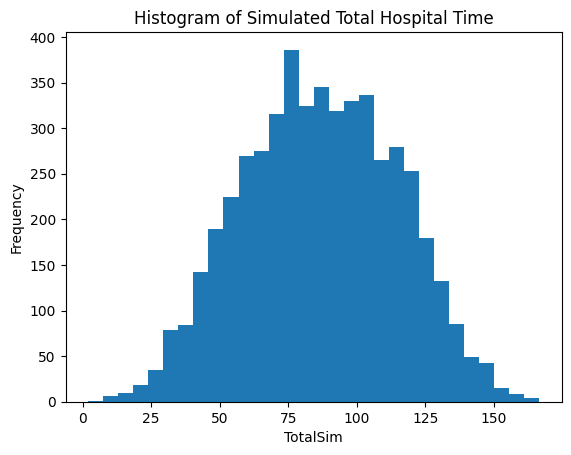

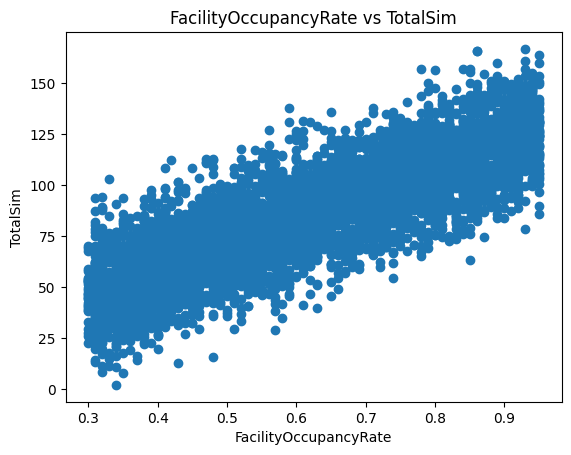

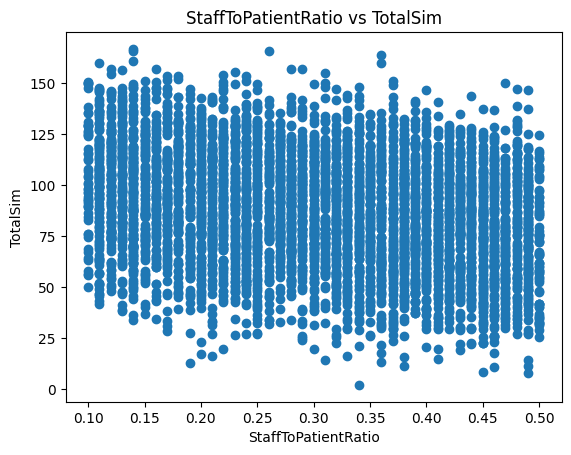

In [7]:
# STEP 4️⃣ HISTOGRAM
plt.figure()
plt.hist(data["TotalSim"], bins=30)
plt.title("Histogram of Simulated Total Hospital Time")
plt.xlabel("TotalSim")
plt.ylabel("Frequency")
plt.show()

# STEP 5️⃣ SCATTER OCCUPANCY
plt.figure()
plt.scatter(data["FacilityOccupancyRate"], data["TotalSim"])
plt.title("FacilityOccupancyRate vs TotalSim")
plt.xlabel("FacilityOccupancyRate")
plt.ylabel("TotalSim")
plt.show()

# STEP 6️⃣ SCATTER STAFF RATIO
plt.figure()
plt.scatter(data["StaffToPatientRatio"], data["TotalSim"])
plt.title("StaffToPatientRatio vs TotalSim")
plt.xlabel("StaffToPatientRatio")
plt.ylabel("TotalSim")
plt.show()



# Drop NaNs

In [8]:
features = [
    "Department",
    "TriageCategory",
    "ProviderID",
    "AgeNumeric",
    "FacilityOccupancyRate",
    "StaffToPatientRatio",
    "ArrivalHour_sin",
    "ArrivalHour_cos",
    "LoadImpact"
]

data_model = data[features + ["TotalSim"]].dropna()

X = data_model[features]
y = data_model["TotalSim"]

# Train/test split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         ["Department", "TriageCategory", "ProviderID"]),
        ("num", "passthrough",
         ["AgeNumeric", "FacilityOccupancyRate",
          "StaffToPatientRatio", "ArrivalHour_sin",
          "ArrivalHour_cos", "LoadImpact"])
    ]
)



# Train consult model

In [11]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline.fit(X_train, y_train)

pred = pipeline.predict(X_test)

print("\n=== CONSULT SIM RESULTS ===")
print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))


=== CONSULT SIM RESULTS ===
MAE: 11.139885518736792
R2: 0.7632230265520012


# Train total model

In [12]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train2, y_train2)

pred2 = pipeline.predict(X_test2)

print("\n=== TOTAL SIM RESULTS ===")
print("MAE:", mean_absolute_error(y_test2, pred2))
print("R2:", r2_score(y_test2, pred2))


=== TOTAL SIM RESULTS ===
MAE: 11.139885518736792
R2: 0.7632230265520012


# Show 5 predictions for sample

In [13]:
sample = X_test.sample(5, random_state=1)
total_pred = pipeline.predict(sample)

results = sample.copy()
results["Predicted_TotalTime"] = total_pred.round(2)

results

,Department,TriageCategory,ProviderID,AgeNumeric,FacilityOccupancyRate,StaffToPatientRatio,ArrivalHour_sin,ArrivalHour_cos,LoadImpact,Predicted_TotalTime
734,Radiology,Semi-urgent,DR50,30.0,0.80,0.22,0.866025,-0.500000,0.6240,106.029999
4870,Pediatrics,Non-urgent,DR3,30.0,0.69,0.38,0.707107,-0.707107,0.4278,82.779999
4415,Pediatrics,Non-urgent,DR35,30.0,0.52,0.26,-0.866025,-0.500000,0.3848,83.500000
683,Cardiology,Semi-urgent,DR34,30.0,0.32,0.49,-0.707107,-0.707107,0.1632,53.619999
4092,Radiology,Semi-urgent,DR40,30.0,0.82,0.41,-0.707107,-0.707107,0.4838,99.900002


# ACTUAL VS PREDICTED

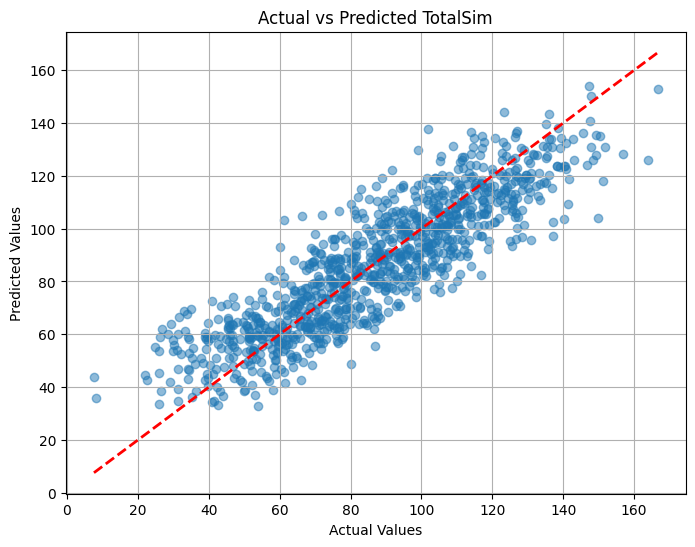

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Actual vs Predicted TotalSim")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.grid(True)
plt.show()

# CROSS VALIDATION

In [15]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=kf, scoring="r2")

print("\nCross-Validation R2 Scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())


Cross-Validation R2 Scores: [0.76322303 0.76927934 0.76249216 0.74708174 0.76095686]
Mean CV R2: 0.7606066251136694


# LIVE SIMULATION SECTION


------ SMARTQ LIVE SIMULATION ------
Normal Day: 68.59 minutes
Peak Congestion: 96.17 minutes
Staff Shortage: 107.23 minutes


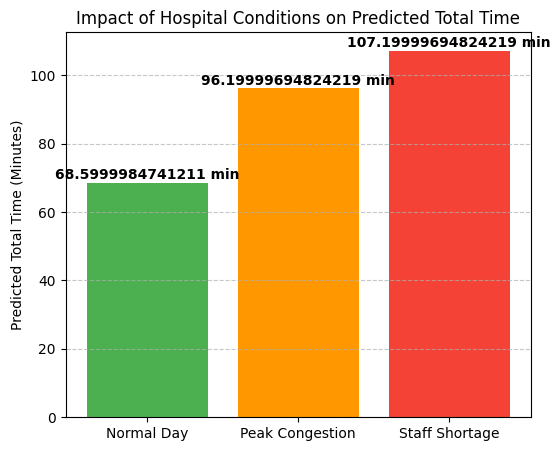

In [16]:
def create_patient(occupancy, staff_ratio):

    patient = {
        "Department": "Cardiology",
        "TriageCategory": "High",
        "ProviderID": "P12",
        "AgeNumeric": 65,
        "FacilityOccupancyRate": occupancy,
        "StaffToPatientRatio": staff_ratio,
        "ArrivalHour_sin": np.sin(2*np.pi*14/24),
        "ArrivalHour_cos": np.cos(2*np.pi*14/24),
        "LoadImpact": occupancy * (1 - staff_ratio)
    }

    return pd.DataFrame([patient])


print("\n------ SMARTQ LIVE SIMULATION ------")

# Normal
normal = create_patient(0.55, 0.60)
normal_pred = pipeline.predict(normal)[0]

# Peak congestion
peak = create_patient(0.90, 0.60)
peak_pred = pipeline.predict(peak)[0]

# Staff shortage
shortage = create_patient(0.75, 0.30)
shortage_pred = pipeline.predict(shortage)[0]

print("Normal Day:", round(normal_pred,2), "minutes")
print("Peak Congestion:", round(peak_pred,2), "minutes")
print("Staff Shortage:", round(shortage_pred,2), "minutes")

# Visualization of Live Simulation Results
scenarios = ["Normal Day", "Peak Congestion", "Staff Shortage"]
predictions = [normal_pred, peak_pred, shortage_pred]

plt.figure(figsize=(6, 5))
plt.bar(scenarios, predictions, color=['#4CAF50', '#FF9800', '#F44336'])
plt.title("Impact of Hospital Conditions on Predicted Total Time")
plt.ylabel("Predicted Total Time (Minutes)")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding values on top of bars
for i, val in enumerate(predictions):
    plt.text(i, val + 1, f"{round(val, 1)} min", ha='center', fontweight='bold')

plt.show()

# FEATURE IMPORTANCE

In [17]:
ohe = pipeline.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat = ohe.get_feature_names_out(["Department","TriageCategory","ProviderID"])

# Adding 'LoadImpact' to the list to match the preprocessor definition
all_features = list(encoded_cat) + [
    "AgeNumeric",
    "FacilityOccupancyRate",
    "StaffToPatientRatio",
    "ArrivalHour_sin",
    "ArrivalHour_cos",
    "LoadImpact"
]

importances = pipeline.named_steps["model"].feature_importances_

indices = np.argsort(importances)[::-1]

print("\nTop 15 Important Features:")
for i in indices[:15]:
    print(all_features[i], ":", round(importances[i],4))


Top 15 Important Features:
LoadImpact : 0.3084
FacilityOccupancyRate : 0.0521
Department_Neurology : 0.0348
Department_Cardiology : 0.0224
ProviderID_DR38 : 0.0147
ProviderID_DR14 : 0.0137
ProviderID_DR32 : 0.0136
ProviderID_DR46 : 0.013
ProviderID_DR39 : 0.013
ProviderID_DR29 : 0.0127
ProviderID_DR40 : 0.0126
ProviderID_DR47 : 0.0125
ProviderID_DR5 : 0.0123
ProviderID_DR50 : 0.0118
ProviderID_DR27 : 0.0117


# Inference Functions

In [18]:
def smartq_predict(pipeline, input_data):
    df = pd.DataFrame([input_data])

    age_map = {
        "Child (0-17)": 10,
        "Adult (18-40)": 30,
        "Middle-aged (41-60)": 50,
        "Senior (61+)": 70
    }

    # Pre-processing logic needed for the pipeline
    df["AgeNumeric"] = df["AgeGroup"].map(age_map).fillna(30)
    df["ArrivalHour_sin"] = np.sin(2*np.pi*df["ArrivalHour"]/24)
    df["ArrivalHour_cos"] = np.cos(2*np.pi*df["ArrivalHour"]/24)
    df["LoadImpact"] = df["FacilityOccupancyRate"] * (1 - df["StaffToPatientRatio"])

    return round(pipeline.predict(df)[0], 2)

def predict_with_confidence(pipeline, input_data):
    df = pd.DataFrame([input_data])

    age_map = {
        "Child (0-17)": 10,
        "Adult (18-40)": 30,
        "Middle-aged (41-60)": 50,
        "Senior (61+)": 70
    }

    df["AgeNumeric"] = df["AgeGroup"].map(age_map).fillna(30)
    df["ArrivalHour_sin"] = np.sin(2*np.pi*df["ArrivalHour"]/24)
    df["ArrivalHour_cos"] = np.cos(2*np.pi*df["ArrivalHour"]/24)
    df["LoadImpact"] = df["FacilityOccupancyRate"] * (1 - df["StaffToPatientRatio"])

    mean_pred = pipeline.predict(df)[0]
    std_dev = 10.7

    lower = mean_pred - 1.96 * std_dev
    upper = mean_pred + 1.96 * std_dev

    return round(mean_pred, 2), round(lower, 2), round(upper, 2)

# Probabilistic Modeling

In [19]:
def probabilistic_prediction(pipeline, input_data, simulations=100):

    base_pred = smartq_predict(pipeline, input_data)

    simulated_preds = []

    for _ in range(simulations):
        noise = np.random.normal(0, 5)
        simulated_preds.append(base_pred + noise)

    mean = np.mean(simulated_preds)
    std = np.std(simulated_preds)

    return round(mean,2), round(std,2)

# Drift Detection

In [20]:
baseline_stats = {
    "occupancy_mean": X_train["FacilityOccupancyRate"].mean(),
    "occupancy_std": X_train["FacilityOccupancyRate"].std()
}

def detect_drift(new_data, baseline):

    current_mean = new_data["FacilityOccupancyRate"].mean()

    drift_score = abs(current_mean - baseline["occupancy_mean"])

    if drift_score > 2 * baseline["occupancy_std"]:
        return "DRIFT DETECTED"

    return "Stable"

# RANDOM TEST (LIVE DEMO)

In [21]:
print("\n------ RANDOM PATIENT TEST ------")

random_patient = {
    "Department": "Neurology",
    "TriageCategory": "High",
    "ProviderID": "P22",
    "AgeGroup": "Senior (61+)",
    "ArrivalHour": 18,
    "FacilityOccupancyRate": 0.82,
    "StaffToPatientRatio": 0.40
}

prediction = smartq_predict(pipeline, random_patient)
mean_ci, lower_ci, upper_ci = predict_with_confidence(pipeline, random_patient)
prob_mean, prob_std = probabilistic_prediction(pipeline, random_patient)

print("Point Prediction:", prediction, "minutes")
print("95% Confidence Interval:", lower_ci, "-", upper_ci)
print("Probabilistic Mean:", prob_mean, "Std Dev:", prob_std)


------ RANDOM PATIENT TEST ------
Point Prediction: 128.73 minutes
95% Confidence Interval: 107.76 - 149.71
Probabilistic Mean: 128.56 Std Dev: 5.34


# Save the Model for connecting backemd

In [27]:
joblib.dump(pipeline, "smartq_model.joblib", compress=3)

['smartq_model.joblib']

# ONNX conversion

In [28]:
# Proper XGBoost native ONNX export
xgb_model = pipeline.named_steps["model"]

# Get number of features after preprocessing
import numpy as np
sample = X_train.iloc[:1]
transformed = pipeline.named_steps["preprocessor"].transform(sample)
n_features = transformed.shape[1]
print("Number of features after preprocessing:", n_features)

# Export properly
from xgboost import XGBRegressor
booster = xgb_model.get_booster()
booster.dump_model("xgb_dump.json", with_stats=True)

# Correct ONNX export
xgb_model.save_model("smartq_xgb.ubj")  # save as binary first

# Now convert using onnxmltools properly
from onnxmltools.convert import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

onnx_model = convert_xgboost(
    xgb_model, 
    initial_types=[("input", FloatTensorType([None, n_features]))]
)

with open("smartq_xgb.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("ONNX saved successfully!")

Number of features after preprocessing: 71
ONNX saved successfully!


In [29]:
import onnxruntime as rt

session = rt.InferenceSession("smartq_xgb.onnx")

print("Input names:", [inp.name for inp in session.get_inputs()])
print("Input shapes:", [inp.shape for inp in session.get_inputs()])
print("Output names:", [out.name for out in session.get_outputs()])

Input names: ['input']
Input shapes: [[None, 71]]
Output names: ['variable']


In [30]:
# Get the exact feature order after preprocessing
ohe = pipeline.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat = ohe.get_feature_names_out(["Department", "TriageCategory", "ProviderID"])

numeric_features = [
    "AgeNumeric",
    "FacilityOccupancyRate",
    "StaffToPatientRatio",
    "ArrivalHour_sin",
    "ArrivalHour_cos",
    "LoadImpact"
]

all_features = list(encoded_cat) + numeric_features
print("Total features:", len(all_features))
print("\nAll features in order:")
for i, f in enumerate(all_features):
    print(i, f)

Total features: 71

All features in order:
0 Department_Cardiology
1 Department_Emergency
2 Department_General Surgery
3 Department_Internal Medicine
4 Department_Neurology
5 Department_Obstetrics
6 Department_Oncology
7 Department_Orthopedics
8 Department_Pediatrics
9 Department_Radiology
10 TriageCategory_Emergency
11 TriageCategory_Immediate
12 TriageCategory_Non-urgent
13 TriageCategory_Semi-urgent
14 TriageCategory_Urgent
15 ProviderID_DR1
16 ProviderID_DR10
17 ProviderID_DR11
18 ProviderID_DR12
19 ProviderID_DR13
20 ProviderID_DR14
21 ProviderID_DR15
22 ProviderID_DR16
23 ProviderID_DR17
24 ProviderID_DR18
25 ProviderID_DR19
26 ProviderID_DR2
27 ProviderID_DR20
28 ProviderID_DR21
29 ProviderID_DR22
30 ProviderID_DR23
31 ProviderID_DR24
32 ProviderID_DR25
33 ProviderID_DR26
34 ProviderID_DR27
35 ProviderID_DR28
36 ProviderID_DR29
37 ProviderID_DR3
38 ProviderID_DR30
39 ProviderID_DR31
40 ProviderID_DR32
41 ProviderID_DR33
42 ProviderID_DR34
43 ProviderID_DR35
44 ProviderID_DR36
45

In [ ]:
!pip freeze > requirements.txt